# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
* **A "linear" model is one that models a linear relationship between two or more variables. A model is “linear” if it is linear in its coefficients (parameters), meaning the coefficients are only multiplied by input variables and added together to produce the output variable.**

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
* **The coefficient in a dummy/one-hot-encoded variable can be interpreted as affecting the prediction by the coefficient's value depending on the presence of the variable, holding all other variables equal. The intercept corresponds to the expected or baseline value when all dummy variables are not present and set to 0.**

3. Can linear regression be used for classification? Explain why, or why not.
* **In tyring to use linear regression for classificaiton, the predicted y from a linear model can take on any value, even outside the range of 0 to 1, which makes it unsuitable for classification tasks. For binary classification, we need predicted probabilities to lie between 0 and 1. Additionally, linear regression assumes normally distributed errors and constant variance, which are not appropriate for classification problems. Logistic regression addresses these issues by constraining predictions to the [0 , 1] range.**

4. What are signs that your linear model is over-fitting?
* **An indication that your linear model is overfitting is when it performs disproportionately better on training data compared to unseen test data. The mean squared error is a metric used to evaluate this, and a much lower training MSE than test MSE suggests the model is fitting noise rather than generalizeable patterns. Other signs include overly large or unstable coefficients and a model that becomes very sensitive to small changes in the data.**

5. Clearly explain multi-colinearity using the two-stage least squares technique.
* **Multi-colinearity is when two or more feature variables are highly correlated, making it difficult to isolate their individual effects on the response because their coefficients become unstable and hard to interpret. In the first part of the two-stage least squares technique, one feature variable ($x_1$) is regressed against other feature variables ($x_2$, $x_3$, etc). The result is a predicted version of $x_1$ and a residual which represents the unique information not explained by the other feature variables. In the second stage, this residual is used in place of $x_1$ in the original regression. The regression coefficient now reflects how the response changes with only the independent variation in $x_1$. If $x_1$ is highly colienar with other feature variables, the residual will be very small since most of $x_1$ is already explained by them.**

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
* **Nonlinear relationships can be incorporated by transforming the features while still using a linear model in the coefficients.**

7. What is the interpretation of the slope coefficient in a linear regression?
* **The slope represents how much the predicted value changes for a one unit increase in a given feature variable, holding all other variables constant.**

8. Compare the train/test split and $k$-fold cross validation.
* **Train/test split divides the data into a single training set and a single test set, so the model is trained once and evaluated once. In contrast, 
$k$-fold cross-validation splits the data into $k$ parts and repeatedly trains and tests the model $k$ times, each time using a different fold as the test set. This makes $k$-fold cross-validation more computationally expensive, but it provides a more reliable estimate of model performance since it uses all data points and reduces variance.**

9. How is the $k$ in $k$-fold cross validation typically selected?
* **The most common choices are $k=5$ or $k=10$, as these have been shown to balance bias and variance in the error estimate. In general, larger $k$ leads to lower bias but higher variance and more computation, while smaller $k$ is faster but produces a noisier estimate.**



**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

In [227]:
import pandas as pd
import numpy as np

airbnb = pd.read_csv("./data/Q1_clean.csv")
airbnb.columns = airbnb.columns.str.strip()
airbnb.head()


,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt



1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.

* **Manhattan is the most expensive borough on average**


In [228]:
airbnb.columns

Index(['Price', 'Review Scores Rating', 'Neighbourhood', 'Property Type',
       'Room Type'],
      dtype='object')

In [229]:
airbnb.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean().sort_values("Price", ascending=False)

,Price,Review Scores Rating
Neighbourhood,,
Manhattan,183.664286,91.801496
Staten Island,146.166667,90.843750
Brooklyn,127.747378,92.363497
Queens,96.857233,91.549057
Bronx,75.276498,91.654378


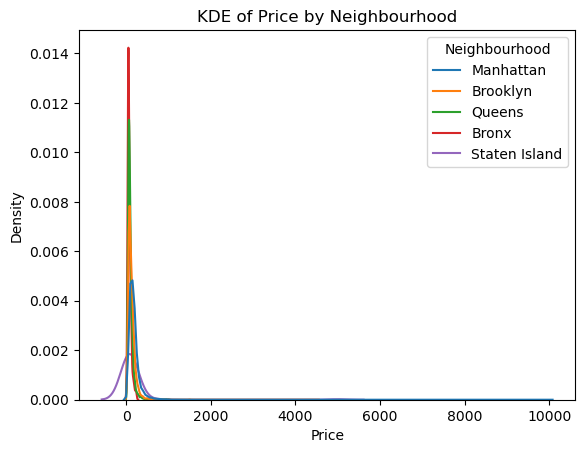

In [230]:
import matplotlib.pyplot as plt
import seaborn as sns

# KDE plot for Price
plt.figure()
sns.kdeplot(data=airbnb, x='Price', hue='Neighbourhood', common_norm=False)
plt.title('KDE of Price by Neighbourhood')
plt.xlabel('Price')
plt.show()


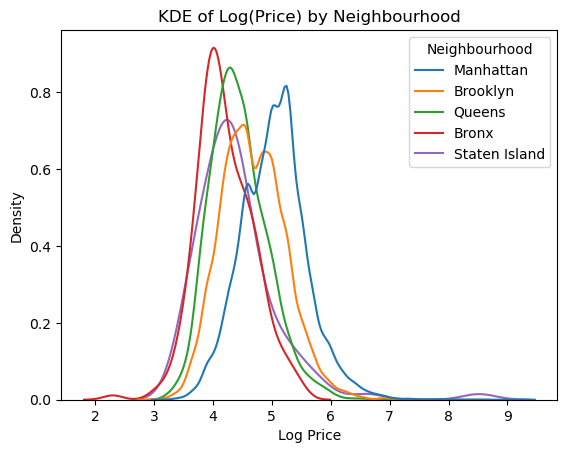

In [231]:
# KDE plot for Log Price

airbnb['log_price'] = np.log(airbnb['Price'])

plt.figure()
sns.kdeplot(data=airbnb, x='log_price', hue='Neighbourhood', common_norm=False)
plt.title('KDE of Log(Price) by Neighbourhood')
plt.xlabel('Log Price')
plt.show()

2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?

* **I dropped the first category (The Bronx). The coefficients corroborate the average price per neighbourhood in part 1. Manhattan is determined to be the most expensive, followed by Staten Island, Brooklyn, with Queens (the baseline) determined to be the least expensive. We can interpret the coefficients as being how much more expensive the neighbourhood is than the Bronx. For example, Manhattan is on average $108.39 more expensive than the Bronx.**



In [232]:
from sklearn.linear_model import LinearRegression

df = airbnb[['Neighbourhood', 'Price', 'Review Scores Rating']].dropna()
X = pd.get_dummies(df['Neighbourhood'], drop_first=True)
y = df['Price']

model = LinearRegression()
model.fit(X, y)

coeffs = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
intercept = model.intercept_

print("Intercept (baseline borough):", intercept)
print("\nCoefficients:")
print(coeffs)


Intercept (baseline borough): 75.2764976958471

Coefficients:
Manhattan        108.387789
Staten Island     70.890169
Brooklyn          52.470881
Queens            21.580735
dtype: float64


3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
* **The slope coefficient represents a price increase of $1.02 for every 1-point improvement in Review Scores Rating.**


In [233]:
X = airbnb[["Review Scores Rating"]]
y = airbnb[["Price"]]

model = LinearRegression()
model = model.fit(X, y)

print("Intercept:", model.intercept_[0])
print("Slope:", model.coef_[0][0])

Intercept: 60.87839065711856
Slope: 1.0208266022675305


4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change? 

* **The slope coefficient on Review Scores Rating increases slightly to 1.08. The neighbourhood coefficients now reflect differences in price controlling for review scores, and they change only slightly from part 1. This suggests that review scores have a small positive effect on price but do not significantly alter the relative price differences across neighbourhoods.**


In [234]:
X = pd.concat([airbnb["Review Scores Rating"], pd.get_dummies(airbnb['Neighbourhood'], drop_first=True)], axis=1)
y = airbnb["Price"]

model = LinearRegression()
model.fit(X, y)

coeffs = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
intercept = model.intercept_

print("Intercept:", intercept)
print("\nCoefficients:")
print(coeffs)

Intercept: -23.812561011683925

Coefficients:
Manhattan               108.228737
Staten Island            71.766552
Brooklyn                 51.704240
Queens                   21.694600
Review Scores Rating      1.081116
dtype: float64


5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
* **Brooklyn, Manhattan and Queens have pretty similar slopes. However, in contrast to the other neighbourhoods, Staten Island has an relatively large and negative slope.**


In [235]:
dummies = pd.get_dummies(airbnb['Neighbourhood'], drop_first=True)

X = pd.concat([airbnb['Review Scores Rating'], dummies], axis=1)

for col in dummies.columns:
    X[f'{col}_x_rating'] = dummies[col] * airbnb['Review Scores Rating']

y = airbnb['Price']

model = LinearRegression()
model.fit(X, y)

coeffs = pd.Series(model.coef_, index=X.columns)
intercept = model.intercept_

print("Intercept:", intercept)
print("\nCoefficients:\n", coeffs)

Intercept: 22.63838492229476

Coefficients:
 Review Scores Rating         0.574311
Brooklyn                   -16.392990
Manhattan                   41.315429
Queens                      28.259701
Staten Island             2963.071040
Brooklyn_x_rating            0.741165
Manhattan_x_rating           0.729703
Queens_x_rating             -0.072294
Staten Island_x_rating     -31.831748
dtype: float64


6. Use cross validation to evaluate the models from parts 4, 5, and 6. 
* **All three models had relatively poor RMSEs. $142-146 is quite a large error compared to the average prices. Model 4 (neighbourhood + reviews) yielded the lowest RMSE. That model 5 (interactions) performed the worse, I believe, suggests that the interactions are leading to overfitting.**


In [236]:
from sklearn.model_selection import cross_val_score

X3 = airbnb[['Review Scores Rating']]

model = LinearRegression()
scores3 = cross_val_score(model, X3, airbnb["Price"], cv=5, scoring='neg_root_mean_squared_error')


In [237]:
X4 = pd.concat([airbnb["Review Scores Rating"], pd.get_dummies(airbnb['Neighbourhood'], drop_first=True)], axis=1)

model = LinearRegression()
scores4 = cross_val_score(model, X4, airbnb["Price"], cv=5, scoring='neg_root_mean_squared_error')

In [238]:
X5 = pd.concat([airbnb['Review Scores Rating'], dummies], axis=1)

for col in dummies.columns:
    X5[f'{col}_x_rating'] = dummies[col] * airbnb['Review Scores Rating']

y = airbnb['Price']

model = LinearRegression()
scores5 = cross_val_score(model, X5, airbnb["Price"], cv=5, scoring='neg_root_mean_squared_error')

In [239]:
print("Model 3 (reviews only) RMSE:", -scores3.mean())
print("Model 4 (neighbourhood + reviews) RMSE:", -scores4.mean())
print("Model 5 (interactions) RMSE:", -scores5.mean())

Model 3 (reviews only) RMSE: 146.32059499618637
Model 4 (neighbourhood + reviews) RMSE: 142.8264812204774
Model 5 (interactions) RMSE: 143.8608615689673


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  * **The Price variable is skewed right and has a mean of ₹741,019.5 and median of ₹666,500. SUVs have the highest mean price (₹1,176,495). However, the most expensive car in the dataset is a sedan (₹2,941,000). With a standard of ₹417,479, SUVs have the highest variance.**


In [240]:
cars = pd.read_csv("./data/cars_hw.csv")
cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [241]:
cars['Price'].describe()

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64

Text(0.5, 1.0, 'KDE of Car Prices')

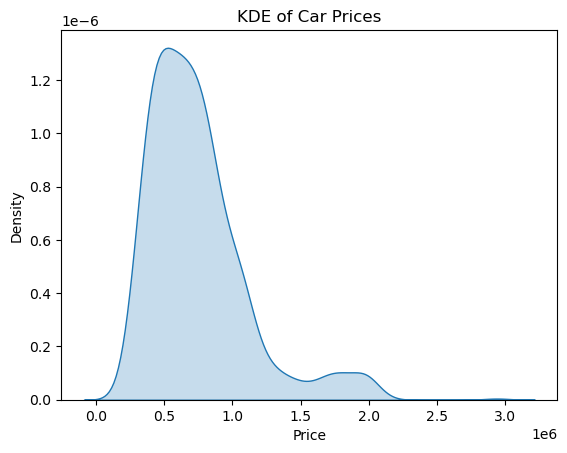

In [242]:
sns.kdeplot(data=cars['Price'], fill=True)
plt.title("KDE of Car Prices")

In [243]:
cars.groupby("Body_Type")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


Text(0.5, 1.0, 'KDE of Car Prices by Body Type')

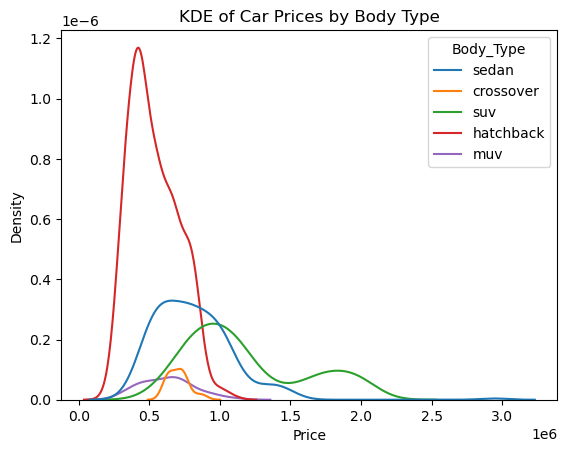

In [244]:
sns.kdeplot(data = cars, x = "Price", hue = "Body_Type")
plt.title("KDE of Car Prices by Body Type")

  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  * **59267 is the slope coefficient. This suggests that adding an additional seat is related to a ₹59,267 increase in the price of a car. After encoding, the differences in price are not linear with the number of seats. The price increases at inconsistent intervals for 5 to 7 seats, but then decreases for 8 seats.**


In [245]:
X = cars[["Seating_Capacity"]]
y = cars[["Price"]]

model = LinearRegression()
model.fit(X, y)

print("Intercept (w/o one-hot encoding): ", model.intercept_[0])
print("Slope (w/o one-hot encoding): ", model.coef_[0][0])

Intercept (w/o one-hot encoding):  439032.0141018258
Slope (w/o one-hot encoding):  59267.99803672191


In [246]:
X = pd.get_dummies(cars["Seating_Capacity"], drop_first=True)
y = cars[["Price"]]

model = LinearRegression()
model.fit(X, y)

coeffs = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
intercept = model.intercept_[0]

print("Intercept (w/ one-hot encoding):", intercept)
print("\nCoefficients (w/ one-hot encoding):")
print(coeffs)

Intercept (w/ one-hot encoding): 188000.00000001083

Coefficients (w/ one-hot encoding):
6    1.456000e+06
7    7.359487e+05
5    5.464839e+05
8    2.718000e+05
dtype: float64


  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
* **Powers of 9 yield the lowest cross validation RMSE for Age**


In [247]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures

cars["Age"] = cars["Make_Year"].max() - cars["Make_Year"]

X = cars[["Age"]]
y = cars[["Price"]]

cv = KFold(n_splits=10, shuffle=True, random_state=42)
cv_mse = {}

for p in range(1, 15):
    poly = PolynomialFeatures(degree=p, include_bias=False)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()  

    mse_scores = -cross_val_score(
        model, X_poly, y,
        cv=cv,
        scoring="neg_root_mean_squared_error"
    )

    cv_mse[p] = mse_scores.mean()
    print(f"Degree {p} \nMSE: {mse_scores.mean()} \nSTD: {mse_scores.std()}\n")

optimal_degree = min(cv_mse, key=cv_mse.get)
print(f"\nOptimal degree: {optimal_degree}")

Degree 1 
MSE: 310765.36071398546 
STD: 28322.05226150261

Degree 2 
MSE: 310779.2959641378 
STD: 28494.476108009203

Degree 3 
MSE: 309697.3446384921 
STD: 28822.899616629606

Degree 4 
MSE: 308871.56777747377 
STD: 28694.82306874905

Degree 5 
MSE: 307368.9819502264 
STD: 28095.274499067444

Degree 6 
MSE: 307522.5236326214 
STD: 28086.577988495606

Degree 7 
MSE: 306433.4190203623 
STD: 28062.99590466547

Degree 8 
MSE: 304974.9262852931 
STD: 29464.687737762077

Degree 9 
MSE: 304139.37351919065 
STD: 29933.84380465301

Degree 10 
MSE: 304190.5936992072 
STD: 29988.606545705454

Degree 11 
MSE: 304203.0000262234 
STD: 29879.64987909941

Degree 12 
MSE: 304751.68708345364 
STD: 28928.295574966378

Degree 13 
MSE: 308566.36067697546 
STD: 28239.831990838306

Degree 14 
MSE: 308503.34401128767 
STD: 28106.107895544163


Optimal degree: 9


  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?
* **The model accurately captures the general downward trend, but it appears that a degree of 9 is leading to overfitting as seen by the specific wiggles in the model curve.**

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


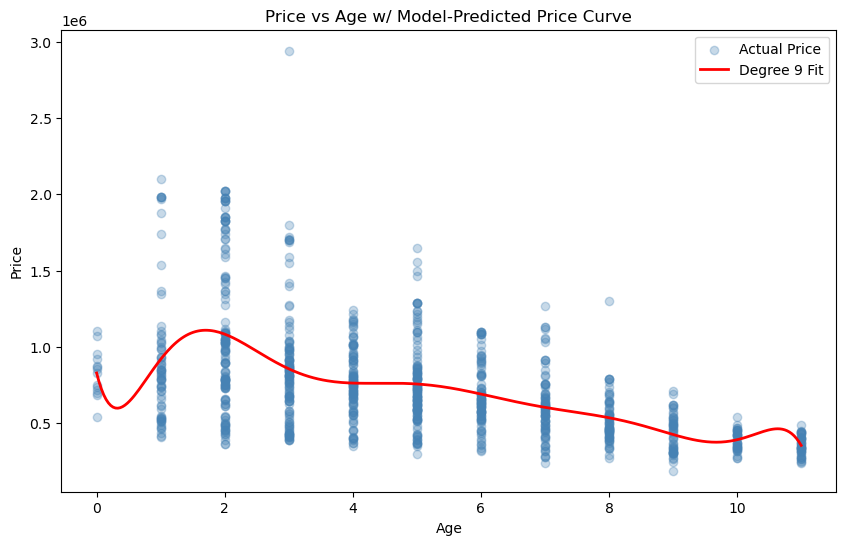

In [248]:
poly = PolynomialFeatures(degree=optimal_degree, include_bias=False)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

Age_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
Age_range_poly = poly.transform(Age_range)
predicted_prices = model.predict(Age_range_poly)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.3, label="Actual Price", color="steelblue")
plt.plot(Age_range, predicted_prices, color="red", linewidth=2, label=f"Degree {optimal_degree} Fit")
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age w/ Model-Predicted Price Curve")
plt.legend()
plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?

* **The proportion of people who survive in the control group is $4/34≈0.12$. The proportion of people who survive in eht treatement group is $24/69≈0.35$. The ATE on three-year survival for heart transplant interventions is roughly 0.23.**

In [249]:
heart = pd.read_csv("./data/heart_hw.csv")
heart.shape


(103, 4)

In [250]:
heart.groupby("transplant")["y"].value_counts().unstack()

y,0,1
transplant,,
control,30,4
treatment,45,24


2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
* **The intercept is the survival rate. The transplant coefficient is the ATE.**

In [251]:
X = pd.get_dummies(heart[["transplant"]], drop_first=True)
y = heart["y"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 0.11764705882352974
Slope: 0.23017902813299182


3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age? What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant? 
* **When controlling for age, the transplant coefficient changes by roughly 0.03. The intercept represents that when a person is 0 years old, their chances of surviving another 3 years is 0.70. The transplant_treatment coefficient represents a 0.265 increase in chances of survival when receiving a transplant, holding the age equal. The age coefficient represents a 0.014 decrease in chances of survival for every 1-year increase in age, when not considering a transplant. From roughly ages 0-53, the ATE is underestimating the impact of a transplant. Beyond 53 years old, the ATE is overestimating the impact of a transplant.**


In [252]:
X = pd.concat([pd.get_dummies(heart[["transplant"]], drop_first=True), heart[["age"]]], axis=1)

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficients:\n", pd.Series(model.coef_, index=X.columns))  


Intercept: 0.701956972174095
Coefficients:
 transplant_treatment    0.264702
age                    -0.013607
dtype: float64


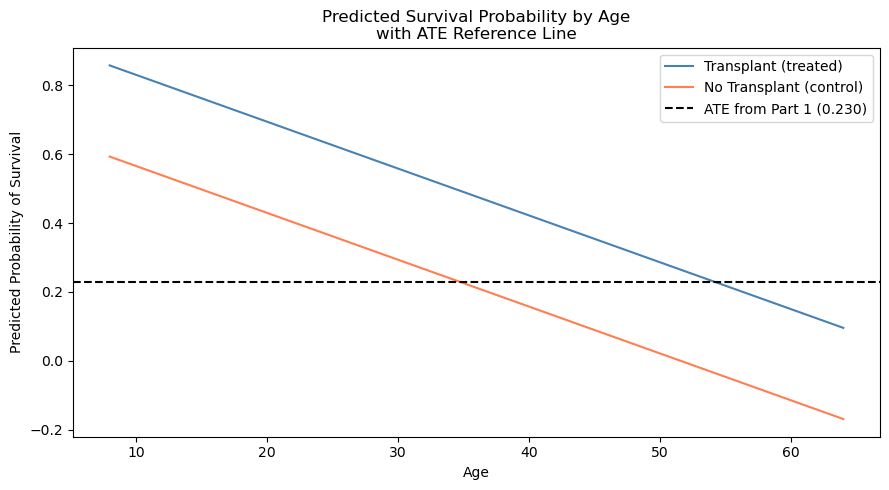

In [253]:
ages = np.linspace(heart["age"].min(), heart["age"].max(), 200)
ATE = 0.23

pred_transplant = model.intercept_ + model.coef_[0] * 1 + model.coef_[1] * ages
pred_no_transplant = model.intercept_ + model.coef_[0] * 0 + model.coef_[1] * ages

# Difference (model-implied treatment effect by age)
pred_diff = pred_transplant - pred_no_transplant  # constant = coef_transplant

plt.figure(figsize=(9, 5))
plt.plot(ages, pred_transplant, label="Transplant (treated)", color="steelblue")
plt.plot(ages, pred_no_transplant, label="No Transplant (control)", color="coral")
plt.axhline(y=ATE, color="black", linestyle="--", linewidth=1.5, label=f"ATE from Part 1 ({ATE:.3f})")

plt.xlabel("Age")
plt.ylabel("Predicted Probability of Survival")
plt.title("Predicted Survival Probability by Age\nwith ATE Reference Line")
plt.legend()
plt.tight_layout()
plt.show()

4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
* **Inlcuding the transplant * age interaction led to a 0.35 decrease in the intercept, suggesting that the baseline chances of suriving three years at age 0 is 0.35. The transplant_treatment coefficient suggests that a transplant increase the chances of survival by about 0.907, holding all other variables equal. The age coefficient suggests that a 1-year increase in age decreases a patient's chances of surivial by 0.005. The interaction coefficient suggests that for every 1-year increase in age, the survival benefit of receiving a transplant decreases by about 1.46 percentage points. From these, I notice an overall pattern of younger patients benefiting far more from transplantation than older patients**

In [254]:
transplant_dummy = pd.get_dummies(heart[["transplant"]], drop_first=True)["transplant_treatment"]

heart["transplant_x_age"] = transplant_dummy * heart["age"]

X = pd.concat([
    transplant_dummy,
    heart[["age", "transplant_x_age"]]
], axis=1)

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("\nCoefficients:\n", pd.Series(model.coef_, index=X.columns))

Intercept: 0.35486517529945905

Coefficients:
 transplant_treatment    0.907751
age                    -0.005524
transplant_x_age       -0.014591
dtype: float64


5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 


In [255]:
rmse1 = -cross_val_score(LinearRegression(), X[["transplant_treatment"]], y, cv=10, scoring='neg_root_mean_squared_error').mean()
print(f"RMSE with transplant only: {rmse1:.4f}")

rmse2 = -cross_val_score(LinearRegression(), X[["transplant_treatment", "age"]], y, cv=10, scoring='neg_root_mean_squared_error').mean()
print(f"RMSE with transplant and age: {rmse2:.4f}")

rmse3 = -cross_val_score(LinearRegression(), X[["transplant_treatment", "age", "transplant_x_age"]], y, cv=10, scoring='neg_root_mean_squared_error').mean()
print(f"RMSE with transplant, age, and interaction: {rmse3:.4f}")

RMSE with transplant only: 0.4355
RMSE with transplant and age: 0.4212
RMSE with transplant, age, and interaction: 0.4129


6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

* **One of my concerns relates to the sample size. With $n=103$, the model is trained on a relatively small dataset, which can lead to high variance and unreliable estimates, especially when including multiple predictors or interaction terms. A more robust model would consider other factors beyond age and transplant. Additionally, the linear model can predict probabilities outside the range of 0 and 1, which is not representative of real-world outcomes.**
